In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('hotel_bookings.csv')

In [4]:
df.head(20)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,7/3/2015
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,7/3/2015
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,7/3/2015
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.00,0,1,Check-Out,7/3/2015
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.00,0,1,Canceled,5/6/2015
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.50,0,0,Canceled,4/22/2015


In [5]:
df.shape

(119390, 32)

Handling missing values

In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
df.drop(['company', 'agent'], axis=1, inplace=True) 

In [8]:
df['country'].value_counts().index[0]

'PRT'

In [9]:
df['country'].fillna(df['country'].value_counts().index[0],inplace=True)

In [10]:
df['country'].isnull().sum()

0

In [11]:
filter1=(df['children']==0) & (df['adults']==0) & (df['babies']==0)

In [12]:
data=df[~filter1]

In [13]:
data['is_canceled'].unique()

array([0, 1])

In [14]:
data['is_canceled'].value_counts()

is_canceled
0    75011
1    44199
Name: count, dtype: int64

In [15]:
data[data['is_canceled']==0]['country'].value_counts()/75011*100

country
PRT    28.526483
GBR    12.888776
FRA    11.289011
ESP     8.509419
DEU     8.088147
         ...    
BHR     0.001333
DJI     0.001333
MLI     0.001333
NPL     0.001333
FRO     0.001333
Name: count, Length: 165, dtype: float64

In [16]:
country_wise_data=data[data['is_canceled']==0]['country'].value_counts().reset_index()
country_wise_data.columns=['country','no_of_guests']
country_wise_data

,country,no_of_guests
0,PRT,21398
1,GBR,9668
2,FRA,8468
3,ESP,6383
4,DEU,6067
...,...,...
160,BHR,1
161,DJI,1
162,MLI,1
163,NPL,1


In [17]:
!pip install plotly

In [18]:
!pip install chart_studio

In [19]:
import plotly
import chart_studio.plotly as py
from plotly.offline import download_plotlyjs ,init_notebook_mode ,plot ,iplot
init_notebook_mode(connected=True)

In [20]:
import plotly.express as px

In [21]:
map_guest=px.choropleth(country_wise_data,
             locations=country_wise_data['country'],
             color=country_wise_data['no_of_guests'],
              hover_name=country_wise_data['country'],
              title='home country of guests'
             )

In [22]:
map_guest.show()

In [23]:
map_guest.write_html("map_guest.html")


In [24]:
data2=data[data['is_canceled']==0]

In [25]:
data2.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Text(0, 0.5, 'price( EUR)')

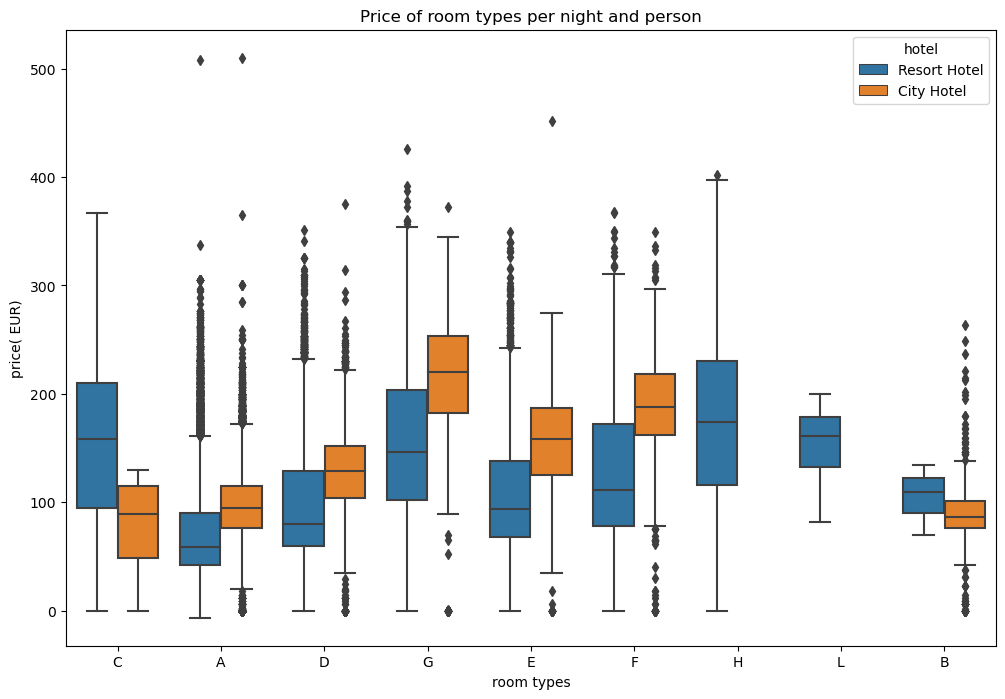

In [26]:

plt.figure(figsize=(12,8))
sns.boxplot(x='reserved_room_type',y='adr' ,hue='hotel',data=data2)

plt.title('Price of room types per night and person')
plt.xlabel('room types')
plt.ylabel('price( EUR)')

In [27]:
data['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [28]:
data_resort=data[(data['hotel']=='Resort Hotel') & data['is_canceled']==0]

In [29]:
data_city= data[(data['hotel']=='City Hotel') & data['is_canceled']==0]

In [30]:
    rush_resort=data_resort['arrival_date_month'].value_counts().reset_index()
rush_resort.columns=['month','no_of_guests']
rush_resort

,month,no_of_guests
0,August,12224
1,July,11208
2,May,10756
3,October,10169
4,April,10019
5,June,9922
6,September,9494
7,March,9005
8,February,7258
9,November,6311


In [31]:
rush_city=data_city['arrival_date_month'].value_counts().reset_index()
rush_city.columns=['month','no_of_guests']
rush_city

,month,no_of_guests
0,August,10261
1,July,9343
2,May,8127
3,October,7879
4,April,7619
5,June,7402
6,September,7391
7,March,7383
8,February,6153
9,November,5111


In [32]:
final_rush=rush_resort.merge(rush_city,on='month')

In [33]:
final_rush

,month,no_of_guests_x,no_of_guests_y
0,August,12224,10261
1,July,11208,9343
2,May,10756,8127
3,October,10169,7879
4,April,10019,7619
5,June,9922,7402
6,September,9494,7391
7,March,9005,7383
8,February,7258,6153
9,November,6311,5111


In [34]:
final_rush.columns=['month','no_of_guests_in_resort','no_of_guests_city']

In [35]:
final_rush

,month,no_of_guests_in_resort,no_of_guests_city
0,August,12224,10261
1,July,11208,9343
2,May,10756,8127
3,October,10169,7879
4,April,10019,7619
5,June,9922,7402
6,September,9494,7391
7,March,9005,7383
8,February,7258,6153
9,November,6311,5111


In [36]:
!pip install sorted-months-weekdays


In [37]:
!pip install sort_dataframeby_monthorweek

In [38]:
import sort_dataframeby_monthorweek as sd

In [39]:
final_rush=sd.Sort_Dataframeby_Month(final_rush,'month')

In [40]:
month = px.line(data_frame=final_rush,x='month',y=['no_of_guests_in_resort', 'no_of_guests_city'])

In [41]:
month.show()

In [42]:
month.write_html("month.html")

In [43]:
pd.crosstab(index=data['stays_in_weekend_nights'],columns=data['stays_in_week_nights'])

stays_in_week_nights,0,1,2,3,4,5,6,7,8,9,...,24,25,26,30,32,33,34,40,42,50
stays_in_weekend_nights,,,,,,,,,,,,,,,,,,,,,
0,645,16436,17949,11557,4478,830,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4569,7325,8976,6150,2407,1188,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2358,6531,6745,4534,2658,8648,847,446,391,81,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,308,300,397,131,61,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,94,347,181,132,86,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
def week_function(row):
    feature1='stays_in_weekend_nights'
    feature2='stays_in_week_nights'
    
    if row[feature2]==0 and row[feature1] >0 :
        return 'stay_just_weekend'
    
    elif row[feature2]>0 and row[feature1] ==0 :
        return 'stay_just_weekdays'
    
    elif row[feature2]>0 and row[feature1] >0 :
        return 'stay_both_weekdays_weekends'
    
    else:
        return 'undefined_data'

In [45]:
data2['weekend_or_weekday']=data2.apply(week_function,axis=1)

/var/folders/sv/5gh132xj2z3_njmjcy2zpd7r0000gn/T/ipykernel_78235/2015990343.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [46]:
data2.head(2)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,weekend_or_weekday
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,Transient,0.0,0,0,Check-Out,7/1/2015,undefined_data
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,Transient,0.0,0,0,Check-Out,7/1/2015,undefined_data


In [47]:
data2['weekend_or_weekday'].value_counts()

weekend_or_weekday
stay_both_weekdays_weekends    37551
stay_just_weekdays             31788
stay_just_weekend               5050
undefined_data                   622
Name: count, dtype: int64

In [48]:
data2=sd.Sort_Dataframeby_Month(data2,'arrival_date_month')

In [49]:
data2.groupby(['arrival_date_month','weekend_or_weekday']).size()

arrival_date_month  weekend_or_weekday         
April               stay_both_weekdays_weekends    3627
                    stay_just_weekdays             2559
                    stay_just_weekend               344
                    undefined_data                   30
August              stay_both_weekdays_weekends    4929
                    stay_just_weekdays             3137
                    stay_just_weekend               509
                    undefined_data                   49
December            stay_both_weekdays_weekends    1901
                    stay_just_weekdays             2123
                    stay_just_weekend               298
                    undefined_data                   69
February            stay_both_weekdays_weekends    2438
                    stay_just_weekdays             2514
                    stay_just_weekend               360
                    undefined_data                   47
January             stay_both_weekdays_weekends    1550


In [50]:
group_data=data2.groupby(['arrival_date_month','weekend_or_weekday']).size().unstack().reset_index()

In [51]:
sorted_data=sd.Sort_Dataframeby_Month(group_data,'arrival_date_month')

In [52]:
sorted_data.set_index('arrival_date_month',inplace=True)

In [53]:
sorted_data

,stay_both_weekdays_weekends,stay_just_weekdays,stay_just_weekend,undefined_data
arrival_date_month,,,,
January,1550,2125,393,47
February,2438,2514,360,47
March,3151,3060,359,50
April,3627,2559,344,30
May,3442,3017,570,74
June,3241,2685,433,36
July,4570,2818,462,57
August,4929,3137,509,49
September,3192,2692,479,22


<Axes: xlabel='arrival_date_month'>

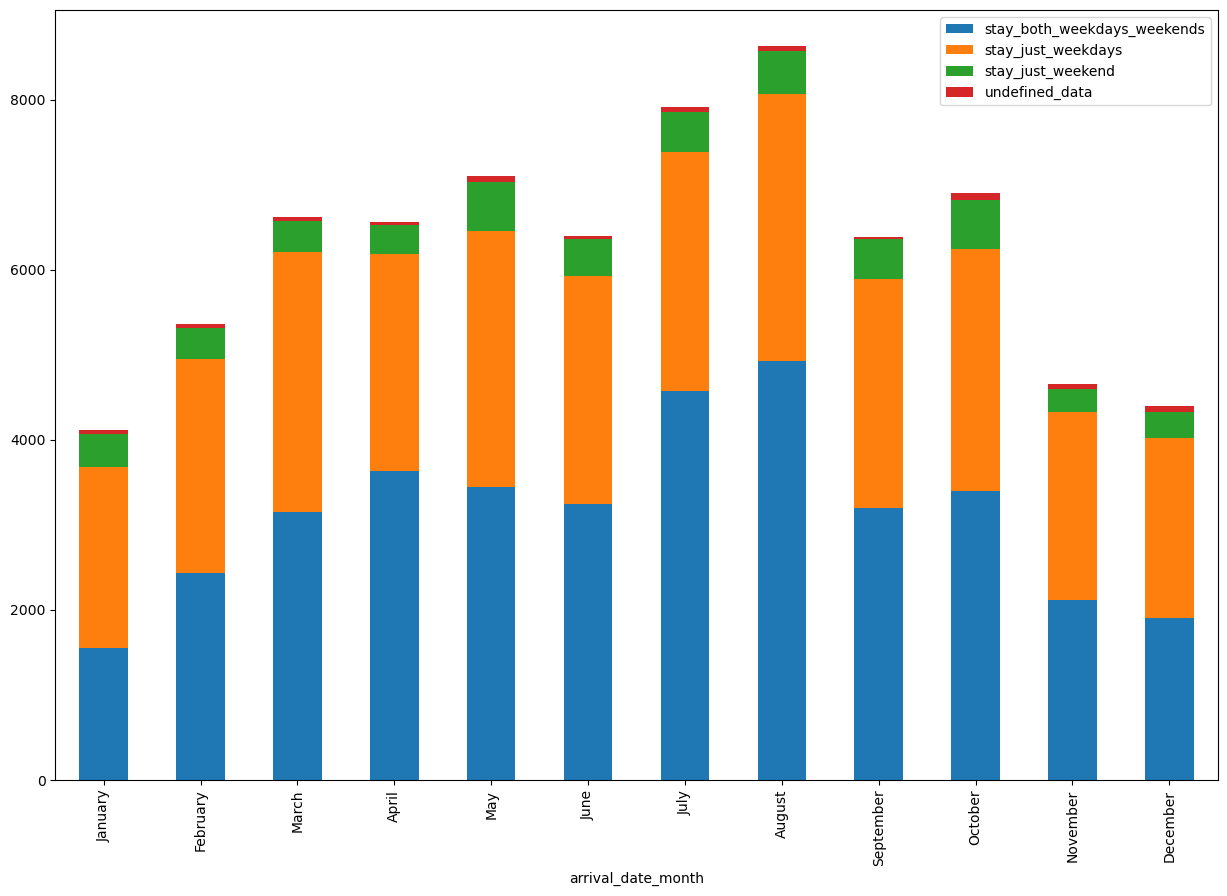

In [54]:
sorted_data.plot(kind='bar',stacked=True,figsize=(15,10))

In [55]:
data2.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'weekend_or_weekday'],
      dtype='object')

In [56]:
def family(row):
    if (row['adults']>0 & (row['children']>0 or row['babies']>0)):
        return 1
    else:
        return 0

In [57]:
data['is_family']=data.apply(family,axis=1)

/var/folders/sv/5gh132xj2z3_njmjcy2zpd7r0000gn/T/ipykernel_78235/2045035792.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [58]:
data['total_costumers']=data['adults']+data['children']+data['babies']

/var/folders/sv/5gh132xj2z3_njmjcy2zpd7r0000gn/T/ipykernel_78235/2854146275.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [59]:
data['total_nights']= data['stays_in_week_nights']+data['stays_in_weekend_nights']

/var/folders/sv/5gh132xj2z3_njmjcy2zpd7r0000gn/T/ipykernel_78235/2312366837.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [60]:
data.head(2)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_family,total_costumers,total_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,1,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,1,2.0,0


Handling categorical features

In [61]:
data['deposit_type'].unique()

array(['No Deposit', 'Refundable', 'Non Refund'], dtype=object)

In [62]:
dict1={'No Deposit':0, 'Non Refund':1, 'Refundable': 0}

In [63]:
data['deposit_given']=data['deposit_type'].map(dict1)

/var/folders/sv/5gh132xj2z3_njmjcy2zpd7r0000gn/T/ipykernel_78235/3053414093.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [64]:
data.drop(columns=['adults', 'children', 'babies', 'deposit_type'],axis=1,inplace=True)

/var/folders/sv/5gh132xj2z3_njmjcy2zpd7r0000gn/T/ipykernel_78235/1470432511.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [65]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'days_in_waiting_list',
       'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status',
       'reservation_status_date', 'is_family', 'total_costumers',
       'total_nights', 'deposit_given'],
      dtype='object')

In [66]:
cate_features=[col for col in data.columns if data[col].dtype=='object']

In [67]:
num_features=[col for col in data.columns if data[col].dtype!='object']

In [68]:
data_cat=data[cate_features]

In [69]:
c= data.groupby(['hotel'])['is_canceled'].mean().to_dict()

In [70]:
c

{'City Hotel': 0.4178593534858457, 'Resort Hotel': 0.27767373336329815}

In [71]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [72]:
data_cat['cancellation']=data['is_canceled']

In [73]:
cols = [col for col in data_cat.columns if col != 'cancellation']


In [74]:
data_cat.columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'customer_type', 'reservation_status', 'reservation_status_date',
       'cancellation'],
      dtype='object')

In [75]:
### Perform Mean Encoding Technique 

for col in cols:
    dict2=data_cat.groupby([col])['cancellation'].mean().to_dict()
    data_cat[col]=data_cat[col].map(dict2)

In [76]:
dataframe=pd.concat([data_cat,data[num_features]],axis=1)

In [77]:
dataframe.drop(['cancellation'],axis=1,inplace=True)

Handling Outliers

<Axes: xlabel='lead_time', ylabel='Density'>

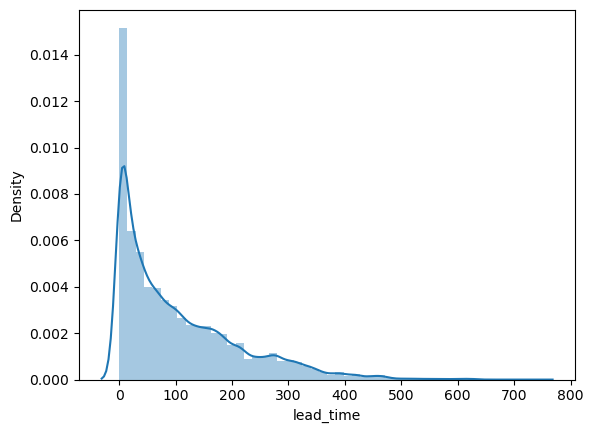

In [78]:
sns.distplot(dataframe['lead_time'])

In [79]:
def handle_outlier(col):
    dataframe[col]=np.log1p(dataframe[col])

In [80]:
handle_outlier('lead_time')

<Axes: xlabel='lead_time', ylabel='Density'>

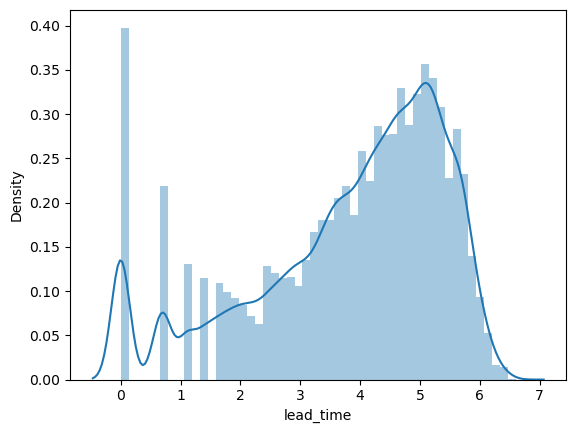

In [81]:
sns.distplot(dataframe['lead_time'])

In [82]:
dataframe[dataframe['adr']<0]

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,customer_type,reservation_status,...,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,is_family,total_costumers,total_nights,deposit_given
14969,0.277674,0.322277,0.374106,0.20231,0.611086,0.174868,0.391567,0.352528,0.254504,0.0,...,2,2,0,-6.38,0,0,1,2.0,10,0


In [83]:
handle_outlier('adr')

In [84]:
dataframe['adr'].isnull().sum()

1

<Axes: xlabel='adr', ylabel='Density'>

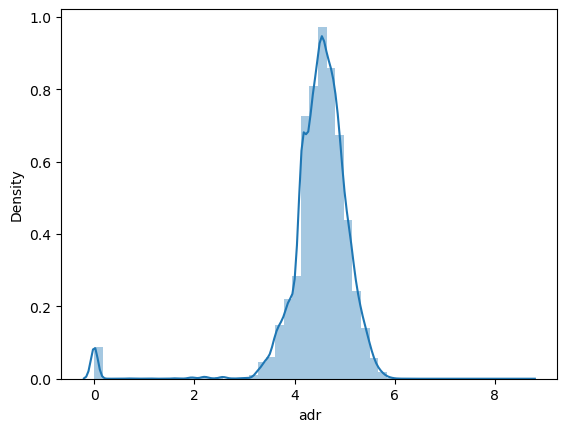

In [85]:
sns.distplot(dataframe['adr'].dropna())

In [86]:
dataframe.dropna(inplace=True)

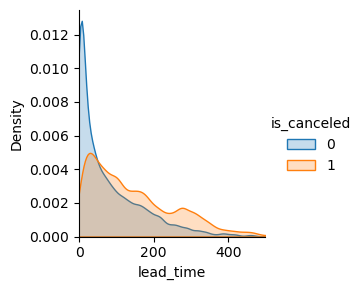

In [87]:
sns.FacetGrid(data,hue='is_canceled',xlim=(0,500)).map(sns.kdeplot,'lead_time',shade=True).add_legend()

Feature Importance 

In [88]:
corr=dataframe.corr()

In [89]:
corr

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,customer_type,reservation_status,...,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,is_family,total_costumers,total_nights,deposit_given
hotel,1.000000,0.051176,0.061781,-0.040649,0.102591,0.182203,0.198215,0.280928,-0.008357,0.137049,...,-0.004450,-0.076561,0.072728,0.154101,-0.218962,-0.043509,-0.030792,-0.038772,-0.249728,0.172423
arrival_date_month,0.051176,1.000000,-0.010207,-0.052426,0.047922,0.077047,-0.038787,0.015464,-0.029647,0.069870,...,-0.021955,-0.011014,0.029163,0.228210,-0.021912,0.002748,0.005755,0.079090,0.045683,0.057360
meal,0.061781,-0.010207,1.000000,0.022473,-0.026024,-0.025517,0.010040,0.013920,0.105784,0.050580,...,0.011108,-0.027192,-0.031561,-0.019901,0.003456,0.006872,-0.004981,-0.003449,-0.055694,0.047599
country,-0.040649,-0.052426,0.022473,1.000000,0.078941,-0.130041,0.153234,0.125472,-0.029271,0.357197,...,0.091811,-0.061481,0.067059,-0.160465,0.007621,-0.200869,0.014919,-0.117369,-0.160742,0.395707
market_segment,0.102591,0.047922,-0.026024,0.078941,1.000000,0.540175,0.182929,0.209421,-0.265537,0.266999,...,-0.117560,-0.057613,0.096418,-0.003851,-0.145738,-0.155578,0.011989,-0.023940,-0.004533,0.397352
distribution_channel,0.182203,0.077047,-0.025517,-0.130041,0.540175,1.000000,0.070625,0.119254,-0.022983,0.177017,...,-0.142675,-0.118406,0.048042,0.126903,-0.146589,0.074924,-0.002511,0.087751,0.085118,0.115268
reserved_room_type,0.198215,-0.038787,0.010040,0.153234,0.182929,0.070625,1.000000,0.722711,-0.143464,0.072828,...,0.022524,-0.040164,0.068333,-0.186027,-0.093413,-0.161375,0.048158,-0.246340,-0.188898,0.201915
assigned_room_type,0.280928,0.015464,0.013920,0.125472,0.209421,0.119254,0.722711,1.000000,-0.084117,0.201641,...,-0.003208,-0.096295,0.067124,-0.038440,-0.131052,-0.135305,0.043825,-0.229073,-0.103582,0.263374
customer_type,-0.008357,-0.029647,0.105784,-0.029271,-0.265537,-0.022983,-0.143464,-0.084117,1.000000,0.136696,...,0.024731,-0.095475,-0.101850,0.117495,0.061771,0.137165,0.013853,0.124350,0.037752,0.121770
reservation_status,0.137049,0.069870,0.050580,0.357197,0.266999,0.177017,0.072828,0.201641,0.136696,1.000000,...,-0.057355,-0.144808,0.054308,0.081753,-0.195698,-0.234931,-0.000532,0.044811,0.018579,0.481537


In [90]:
corr['is_canceled'].sort_values(ascending=False)

reservation_status                1.000000
is_canceled                       1.000000
reservation_status_date           0.488319
deposit_given                     0.481537
country                           0.357197
lead_time                         0.320180
market_segment                    0.266999
assigned_room_type                0.201641
distribution_channel              0.177017
hotel                             0.137049
customer_type                     0.136696
previous_cancellations            0.110147
adr                               0.081753
reserved_room_type                0.072828
arrival_date_month                0.069870
days_in_waiting_list              0.054308
meal                              0.050580
total_costumers                   0.044811
stays_in_week_nights              0.025561
total_nights                      0.018579
arrival_date_year                 0.016702
arrival_date_week_number          0.008291
is_family                        -0.000532
stays_in_we

In [91]:
corr['is_canceled'].sort_values(ascending=False).index

Index(['reservation_status', 'is_canceled', 'reservation_status_date',
       'deposit_given', 'country', 'lead_time', 'market_segment',
       'assigned_room_type', 'distribution_channel', 'hotel', 'customer_type',
       'previous_cancellations', 'adr', 'reserved_room_type',
       'arrival_date_month', 'days_in_waiting_list', 'meal', 'total_costumers',
       'stays_in_week_nights', 'total_nights', 'arrival_date_year',
       'arrival_date_week_number', 'is_family', 'stays_in_weekend_nights',
       'arrival_date_day_of_month', 'previous_bookings_not_canceled',
       'is_repeated_guest', 'booking_changes', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [92]:
features_to_drop=['reservation_status', 'reservation_status_date','arrival_date_year',
       'arrival_date_week_number', 'stays_in_weekend_nights',
       'arrival_date_day_of_month']

In [93]:
dataframe.drop(features_to_drop,axis=1,inplace=True)

In [94]:
dataframe.dropna(inplace=True)

In [95]:
x=dataframe.drop('is_canceled',axis=1)

In [96]:
y=dataframe['is_canceled']

Model based Feature Selection

In [97]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

In [98]:
feature_sel_model=SelectFromModel(Lasso(alpha=0.005))

In [99]:
feature_sel_model.fit(x,y)

SelectFromModel(estimator=Lasso(alpha=0.005))

In [100]:
feature_sel_model.get_support() 

array([False, False, False,  True, False, False, False, False, False,
        True, False, False,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True])

In [101]:
cols=x.columns

In [102]:
cols

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'customer_type', 'lead_time', 'stays_in_week_nights',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'is_family', 'total_costumers',
       'total_nights', 'deposit_given'],
      dtype='object')

In [103]:
selected_feature=cols[feature_sel_model.get_support()]

In [104]:
selected_feature

Index(['country', 'lead_time', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'total_costumers', 'total_nights',
       'deposit_given'],
      dtype='object')

In [105]:
x=x[selected_feature]

In [106]:
x

,country,lead_time,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_costumers,total_nights,deposit_given
0,0.562958,5.837730,0,0,3,0,0.000000,0,0,2.0,0,0
1,0.562958,6.603944,0,0,4,0,0.000000,0,0,2.0,0,0
2,0.202310,2.079442,0,0,0,0,4.330733,0,0,1.0,1,0
3,0.202310,2.639057,0,0,0,0,4.330733,0,0,1.0,1,0
4,0.202310,2.708050,0,0,0,0,4.595120,0,1,2.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0.202391,3.178054,0,0,0,0,4.576153,0,0,2.0,7,0
119386,0.185848,4.634729,0,0,0,0,5.422436,0,2,3.0,7,0
119387,0.167193,3.555348,0,0,0,0,5.067079,0,4,2.0,7,0
119388,0.202310,4.700480,0,0,0,0,4.657763,0,0,2.0,7,0


In [107]:
y

0         0
1         0
2         0
3         0
4         0
         ..
119385    0
119386    0
119387    0
119388    0
119389    0
Name: is_canceled, Length: 119205, dtype: int64

Training Logistic Regression 

In [108]:
from sklearn.model_selection import train_test_split

In [109]:
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.25)

In [110]:
from sklearn.linear_model import LogisticRegression


In [111]:
logreg=LogisticRegression()

In [112]:
logreg.fit(X_train,y_train)

LogisticRegression()

In [113]:
pred=logreg.predict(X_test)

In [114]:
pred

array([0, 0, 1, ..., 0, 0, 1])

In [115]:
from sklearn.metrics import confusion_matrix

In [116]:
confusion_matrix(y_test,pred)

array([[17474,  1183],
       [ 4792,  6353]])

In [117]:
from sklearn.metrics import accuracy_score

In [118]:
accuracy_score(y_test,pred) 

0.799510099993289

In [119]:
from sklearn.model_selection import cross_val_score

In [120]:
score=cross_val_score(logreg,x,y,cv=10)

In [121]:
score

array([0.78558846, 0.75069206, 0.8400302 , 0.74129687, 0.72561027,
       0.78565436, 0.73691275, 0.81040268, 0.79958054, 0.89622483])

In [122]:
score.mean()

0.7871993018636673

Training with different Models

In [124]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



In [127]:
models=[]

models.append(('LogisticRegression',LogisticRegression()))
models.append(('Naive_bayes',GaussianNB()))
models.append(('Random Forest',RandomForestClassifier()))
models.append(('Decision_tree',DecisionTreeClassifier()))
models.append(('KNN',KNeighborsClassifier()))

In [128]:
for name,model in models:
    print(name)
    model.fit(X_train,y_train)
    
    predictions=model.predict(X_test)
    
    from sklearn.metrics import confusion_matrix
    cm=confusion_matrix(predictions,y_test)
    print(cm)
    
    from sklearn.metrics import accuracy_score
    acc=accuracy_score(predictions,y_test)
    print(acc)
    print('\n')

LogisticRegression
[[17474  4792]
 [ 1183  6353]]
0.799510099993289


Naive_bayes
[[ 6553   607]
 [12104 10538]]
0.5734850010066439


Random Forest
[[17128  2749]
 [ 1529  8396]]
0.856452587074693


Decision_tree
[[15920  2605]
 [ 2737  8540]]
0.8207502852157573


KNN
[[16645  3342]
 [ 2012  7803]]
0.8203476276759949


